In [1]:
# Importando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Definindo variável para receber os dados e efetuando a leitura.
dados = 'Base Financial Analysis.xlsx'
pd.set_option('display.max_columns', None)
df = pd.read_excel(dados)

In [3]:
# Usamos sample para ver dados aleatórios.
df.sample(3)

,Papel,Cotação,P/L,P/VP,PSR,Div.Yield,P/Ativo,P/Cap.Giro,P/EBIT,P/Ativ Circ.Liq,EV/EBIT,EV/EBITDA,Mrg Ebit,Mrg. Líq.,Liq. Corr.,ROIC,ROE,Liq.2meses,Patrim. Líq,Dív.Brut/ Patrim.,Cresc. Rec.5a
811,PEAB4,39.96,22.13,0.80,6.296,0.0339,0.567,4.09,-31.84,-5.04,-31.65,-135.22,-0.1977,0.2845,4.51,-0.0204,0.0361,8597.49,907574000,0.17,0.4466
123,SJOS3,1.19,-1.92,-0.08,8.910,0.0000,5.247,-0.09,-35.39,-0.08,-86.80,-86.80,-0.2518,-4.6295,0.01,0.0113,0.0433,0.00,-192639000,-0.12,-0.1467
433,BECE3,9.10,-3.42,8.72,0.000,0.0000,0.000,0.00,0.00,0.00,0.00,0.00,0.0000,0.0000,0.00,0.0000,-2.5520,0.00,96496000,0.00,0.1281


In [4]:
# Verifcando as informações
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Papel              997 non-null    str    
 1   Cotação            997 non-null    float64
 2   P/L                997 non-null    float64
 3   P/VP               997 non-null    float64
 4   PSR                997 non-null    float64
 5   Div.Yield          997 non-null    float64
 6   P/Ativo            997 non-null    float64
 7   P/Cap.Giro         997 non-null    float64
 8   P/EBIT             997 non-null    float64
 9   P/Ativ Circ.Liq    997 non-null    float64
 10  EV/EBIT            997 non-null    float64
 11  EV/EBITDA          997 non-null    float64
 12  Mrg Ebit           997 non-null    float64
 13  Mrg. Líq.          997 non-null    float64
 14  Liq. Corr.         997 non-null    float64
 15  ROIC               997 non-null    float64
 16  ROE                997 non-null    fl

- Não temos dados nulos, que já é considerado um começo.

#### Perguntas:

1. Quantas ações possuem cotação igual a zero?
2. Quantas possuem P/L negativo ou igual a zero?
3. Quantas possuem ROE negativo?


---

#### Respostas:

In [5]:
# R: 1
# Contando o número de ações com Cotação igual a zero.
# Vamos usar shape para contar números de linas.
num_acoes_cotacao_zero = df[df['Cotação'] == 0].shape[0]
print(f"Número de ações com Cotação igual a zero: {num_acoes_cotacao_zero}")

Número de ações com Cotação igual a zero: 32


In [6]:
# R: 2
# Verificando P/L negativo ou zerado.
num_acoes_pl_zeronegativo = df[df['P/L'] <= 0].shape[0]
print(f"Número de ações com P/L menor ou igual a zero: {num_acoes_pl_zeronegativo}")

Número de ações com P/L menor ou igual a zero: 376


In [7]:
# R: 3
# Verificando ROE negativo.
num_acoes_roe_negativo = df[df['ROE'] <= 0].shape[0]
print(f"Número de ações com ROE negativo: {num_acoes_roe_negativo}")

Número de ações com ROE negativo: 263


 - Em resumo, embora não haja dados ausentes, as anomalias principais residem no número significativo de ações com Cotação zero, P/L negativo/zero e ROE negativo, que podem impactar a interpretação da saúde financeira e do desempenho das empresas representadas nesses dados.

In [8]:
# Vamos verificar quantas valor negativos temos e zerado.
colunas = df.select_dtypes('number').columns
valores_negativos = []

for acao in colunas:
  qtd_negativos = df[df[acao] < 0].shape[0]
  qtd_zerados = df[df[acao] == 0].shape[0]

  valores_negativos.append({
    'Acao': acao,
    'qtd_negativos': qtd_negativos,
    'qtd_zerados': qtd_zerados
  })

df_val_zerados = pd.DataFrame(valores_negativos)
df_val_zerados

,Acao,qtd_negativos,qtd_zerados
0,Cotação,0,32
1,P/L,283,93
2,P/VP,125,94
3,PSR,14,200
4,Div.Yield,0,686
5,P/Ativo,0,149
6,P/Cap.Giro,249,181
7,P/EBIT,237,159
8,P/Ativ Circ.Liq,594,193
9,EV/EBIT,231,129


- Observando que temos valores negativos ou zerados, seria uma boa alternativa trabalhar apenas com valores positivos. Porém, como temos métricas como EV/EBIT, em que quanto menor é melhor, apenas alguns dados serão excluídos:
- Cotação (preço = 0): não é possível saber se vale a pena a aquisição sem valor.
- P/L negativo: indica prejuízo.
- ROE negativo: indica destruição de valor.
- Não optei por excluir mais dados, pois gostaria de obter mais informações. Como, no futuro deste projeto, teremos um ranking, naturalmente esses casos serão desconsiderados.

In [9]:
# criando uma cópia do meu DF
base_tratada = df.copy()

# A nova base será executada com os filtros mencionado acima.
base_tratada = base_tratada[base_tratada['Cotação'] > 0]
base_tratada = base_tratada[base_tratada['P/L'] > 0]
base_tratada = base_tratada[base_tratada['ROE'] > 0]

In [10]:
base_tratada.sample(3)

,Papel,Cotação,P/L,P/VP,PSR,Div.Yield,P/Ativo,P/Cap.Giro,P/EBIT,P/Ativ Circ.Liq,EV/EBIT,EV/EBITDA,Mrg Ebit,Mrg. Líq.,Liq. Corr.,ROIC,ROE,Liq.2meses,Patrim. Líq,Dív.Brut/ Patrim.,Cresc. Rec.5a
870,SUZB3,51.76,9.99,1.45,1.278,0.0000,0.398,2.24,5.76,-0.85,11.88,6.02,0.2218,0.1287,3.20,0.0838,0.1452,3.505270e+08,45118400000,2.06,0.0563
805,SOND3,38.66,3.42,1.31,0.431,0.3689,0.782,2.52,2.81,4.16,1.78,1.52,0.1532,0.1269,2.10,0.4010,0.3839,9.913000e+01,72363000,0.00,0.2988
388,TCSL4,7.82,9.95,0.83,1.105,0.0000,0.475,8.93,5.69,-2.20,5.61,2.18,0.1944,0.1111,1.34,0.0967,0.0833,0.000000e+00,22847800000,0.14,0.0229


#### Classicando os dados Pontuação.

- ROE maior que 10%
- Margem Líquida maior que 5%
- Dív.Brut/Patrim > 1
- P/L > 0 E < 15

In [11]:
# Conforme os dados acima vamos criar essa tabela
base_tratada['Pontuação'] = (
    (base_tratada['ROE'] > 0.10).astype(int) +
    (base_tratada['Mrg. Líq.'] > 0.05).astype(int) +
    (base_tratada['Dív.Brut/ Patrim.'] < 1).astype(int) +
    (base_tratada['P/L'].between(0, 15)).astype(int)
) # Int já converte para 1 ou 0 e depois somamos

# Fixando os filtros
base_tratada.inplace=True

# Exibindo nossa tabela
base_tratada.sample(5)

,Papel,Cotação,P/L,P/VP,PSR,Div.Yield,P/Ativo,P/Cap.Giro,P/EBIT,P/Ativ Circ.Liq,EV/EBIT,EV/EBITDA,Mrg Ebit,Mrg. Líq.,Liq. Corr.,ROIC,ROE,Liq.2meses,Patrim. Líq,Dív.Brut/ Patrim.,Cresc. Rec.5a,Pontuação
580,MILS3,15.60,12.26,2.18,2.055,0.0297,0.816,3.34,5.84,-3.35,8.05,5.68,0.3519,0.1679,2.78,0.1859,0.1775,20762800.0,1678720000,1.37,0.2698,3
467,CASN3,10.45,31.17,4.67,5.593,0.0005,2.015,92.16,17.85,-5.25,21.06,15.91,0.3134,0.1794,1.13,0.1240,0.1498,0.0,2575430000,1.01,0.1631,2
529,TIMP3,13.46,17.13,1.43,1.903,0.0000,0.818,15.37,9.79,-3.78,9.72,3.77,0.1944,0.1111,1.34,0.0967,0.0833,0.0,22847800000,0.14,0.0229,2
743,CYRE3,30.05,7.54,1.32,1.579,0.1063,0.550,1.32,9.34,12.98,11.59,10.74,0.1690,0.1767,3.51,0.0718,0.1745,193932000.0,10433800000,0.72,0.1729,4
67,SULT4,0.43,0.04,0.01,0.025,0.0000,0.002,-0.01,0.38,0.00,0.56,0.55,0.0665,0.5737,0.29,0.0065,0.2008,0.0,616814000,0.01,0.2004,4


#### "Ação Boa?"

- Regras:

  - Se a Pontuação for igual a 4 (ou seja, a ação atende a TODOS os critérios simultaneamente), ela é classificada como "Sim" (boa para investimento).
  - Caso contrário, "Não".
  - Quantas ações foram classificadas como "Sim"?
  - Qual o percentual em relação ao total?

In [12]:
# Adicionando Sim para nota igual 4 e menor que 4 não
base_tratada["Ação Boa?"] = base_tratada['Pontuação'].apply(
    lambda x: "Sim" if x == 4 else 'Nao')

base_tratada.sample(5)

,Papel,Cotação,P/L,P/VP,PSR,Div.Yield,P/Ativo,P/Cap.Giro,P/EBIT,P/Ativ Circ.Liq,EV/EBIT,EV/EBITDA,Mrg Ebit,Mrg. Líq.,Liq. Corr.,ROIC,ROE,Liq.2meses,Patrim. Líq,Dív.Brut/ Patrim.,Cresc. Rec.5a,Pontuação,Ação Boa?
560,YDUQ3,14.68,16.46,1.28,0.734,0.0776,0.414,10.96,4.67,-0.97,9.61,4.95,0.1572,0.0444,1.18,0.1020,0.0780,45254900.0,3134370000,1.69,0.0669,0,Nao
871,ENMT3,51.80,11.34,2.86,1.251,0.1062,0.732,8.68,6.10,-1.47,9.79,8.17,0.2050,0.1103,1.52,0.1398,0.2522,28161.8,3965230000,2.07,0.0643,3,Nao
198,MARI3,2.93,3.04,0.76,0.346,0.0000,0.384,0.95,4.99,1.65,4.89,4.89,0.0694,0.1137,2.23,0.1067,0.2513,0.0,706711000,0.32,0.1189,4,Sim
612,TARP11,18.02,0.82,0.25,26.009,0.0000,0.245,0.00,197.74,0.00,195.29,195.29,0.1315,31.7005,0.00,0.0000,0.2989,0.0,678212000,0.00,-0.7136,4,Sim
460,GOAU3,10.14,12.80,0.69,0.193,0.0297,0.154,0.64,2.27,14.36,3.74,2.33,0.0850,0.0435,2.71,0.0824,0.0542,826488.0,19368000000,0.96,-0.0297,2,Nao


In [13]:
base_tratada.index.name = 'id'

In [14]:
total_acaoboa = (base_tratada['Ação Boa?'] == 'Sim').sum()
qtd_acoes = len(base_tratada)

print(f'Total de ações boas para investimentos')
print(f'{total_acaoboa} ')

print(f'\n')
print(f"Quantidade todas de ações \n{qtd_acoes}")
print(f'\n')

print(f'Porcentagem de ações boas para investir')
print(f'{(total_acaoboa / qtd_acoes) * 100:.2f}%')

Total de ações boas para investimentos
162 


Quantidade todas de ações 
589


Porcentagem de ações boas para investir
27.50%


- Análisando os dados vemos que aplicando o filtro de 977 ações ficaram apenas 589, dessa apenas 94 passaram nos requesitos que da um total de 16% em referencia com a base de 589.

---

### (IV)

- Vamos criar uma cópia para nosso IV

In [15]:
df_iv = base_tratada.copy()

In [16]:
# Colunas para calculo de percentil
colunas = df_iv.columns
colunas = ['P/VP', 'PSR', 'Div.Yield', 'P/Ativo', 'P/Cap.Giro', 'P/EBIT', 'P/Ativ Circ.Liq', 
           'EV/EBIT', 'EV/EBITDA', 'Mrg Ebit', 'Liq. Corr.', 'ROIC', 'Liq.2meses', 'Patrim. Líq', 
           'Cresc. Rec.5a', 'ROE', 'Mrg. Líq.', 'Dív.Brut/ Patrim.','P/L']

In [17]:
# Loop para correr as colunas
for col in colunas:
    p25 = df_iv[col].quantile(0.25)
    p50 = df_iv[col].quantile(0.50)
    p75 = df_iv[col].quantile(0.75)

    faixas = [-float('inf'), p25, p50, p75, float('inf')]
    
    # Remove duplicatas mantendo a ordem
    faixas_unicas = sorted(set(faixas))
    
    # Labels sempre deve ter len(bins) - 1
    nomes = list(range(len(faixas_unicas) - 1))

    df_iv[f'{col}_faixa'] = pd.cut(
        df_iv[col], 
        bins=faixas_unicas, 
        labels=nomes,
        duplicates='drop'
    )

In [18]:
# Manter apenas colunas que terminam com '_faixa'
df_iv = df_iv.filter(like='_faixa')

In [19]:
df_iv = pd.merge(df_iv, base_tratada[['Ação Boa?']], left_index=True, right_index=True, how='left')

In [20]:
display(df_iv.sample(5))

,P/VP_faixa,PSR_faixa,Div.Yield_faixa,P/Ativo_faixa,P/Cap.Giro_faixa,P/EBIT_faixa,P/Ativ Circ.Liq_faixa,EV/EBIT_faixa,EV/EBITDA_faixa,Mrg Ebit_faixa,Liq. Corr._faixa,ROIC_faixa,Liq.2meses_faixa,Patrim. Líq_faixa,Cresc. Rec.5a_faixa,ROE_faixa,Mrg. Líq._faixa,Dív.Brut/ Patrim._faixa,P/L_faixa,Ação Boa?
id,,,,,,,,,,,,,,,,,,,,
928,3,3,0,3,3,3,0,3,3,3,1,3,0,3,3,3,3,1,3,Nao
994,0,2,0,0,1,0,3,0,3,0,3,0,0,0,2,1,3,1,0,Sim
920,1,1,0,1,1,1,1,1,1,2,2,2,0,1,3,3,2,3,0,Nao
965,3,3,0,3,3,3,0,2,2,3,1,3,0,3,3,2,3,1,2,Sim
262,1,2,1,2,3,2,0,1,1,2,2,2,2,0,1,3,3,1,0,Sim


- Após criar as colunas necessárias para criação IV
- Criando o IV para as colunas

In [21]:
# Lista para receber os valores de IV calculados
lista_iv = []

In [22]:
# Função para gerar DF com dados para IV
def gerar_crosstab(df, coluna, target='Ação Boa?'):
    
    tabela = pd.crosstab(
        df[coluna],
        df[target]
    )
    
    tabela.index.name = coluna
    
    return tabela

In [23]:
# Função para calcular IV evita repetir o código
def calculo_iv(tabela):
    
    total_a = tabela['Sim'].sum()
    total_c = tabela['Nao'].sum()
    
    tabela['%Nao'] = tabela['Nao'] / total_c
    tabela['%Sim'] = tabela['Sim'] / total_a

    tabela['%Diferenca'] = (
    tabela['%Sim'] - tabela['%Nao']
    )
    
    tabela['%Absoluto'] = (
        tabela['%Sim'] - tabela['%Nao']
    ).abs()
    
    total_iv = tabela['%Absoluto'].sum()

    lista_iv.append({
    'Col_Name': tabela.index.name,
    'IV_Total': total_iv})
    
    return tabela, total_iv

In [24]:
colunas = df_iv.columns
colunas

Index(['P/VP_faixa', 'PSR_faixa', 'Div.Yield_faixa', 'P/Ativo_faixa',
       'P/Cap.Giro_faixa', 'P/EBIT_faixa', 'P/Ativ Circ.Liq_faixa',
       'EV/EBIT_faixa', 'EV/EBITDA_faixa', 'Mrg Ebit_faixa',
       'Liq. Corr._faixa', 'ROIC_faixa', 'Liq.2meses_faixa',
       'Patrim. Líq_faixa', 'Cresc. Rec.5a_faixa', 'ROE_faixa',
       'Mrg. Líq._faixa', 'Dív.Brut/ Patrim._faixa', 'P/L_faixa', 'Ação Boa?'],
      dtype='str')

In [25]:
colunas = ['P/VP_faixa', 'PSR_faixa', 'Div.Yield_faixa', 'P/Ativo_faixa',
       'P/Cap.Giro_faixa', 'P/EBIT_faixa', 'P/Ativ Circ.Liq_faixa',
       'EV/EBIT_faixa', 'EV/EBITDA_faixa', 'Mrg Ebit_faixa',
       'Liq. Corr._faixa', 'ROIC_faixa', 'Liq.2meses_faixa',
       'Patrim. Líq_faixa', 'Cresc. Rec.5a_faixa', 'ROE_faixa',
       'Mrg. Líq._faixa', 'Dív.Brut/ Patrim._faixa', 'P/L_faixa']

In [26]:
for col in colunas:
    # Crosstab
    tabela = gerar_crosstab(df_iv, col)
    
    # Cálculo IV
    tabela, total_iv = calculo_iv(tabela)
    
    # Resultado
    print(f'{col} IV: {total_iv.round(3)}')
    display(tabela)
    print('')
    print('======================================================================')
    print('')

P/VP_faixa IV: 0.233


Ação Boa?,Nao,Sim,%Nao,%Sim,%Diferenca,%Absoluto
P/VP_faixa,,,,,,
0,115,36,0.269321,0.222222,-0.047099,0.047099
1,97,48,0.227166,0.296296,0.069130,0.069130
2,101,46,0.236534,0.283951,0.047417,0.047417
3,114,32,0.266979,0.197531,-0.069448,0.069448




PSR_faixa IV: 0.53


Ação Boa?,Nao,Sim,%Nao,%Sim,%Diferenca,%Absoluto
PSR_faixa,,,,,,
0,135,13,0.316159,0.080247,-0.235912,0.235912
1,110,37,0.257611,0.228395,-0.029216,0.029216
2,87,60,0.203747,0.370370,0.166623,0.166623
3,95,52,0.222482,0.320988,0.098505,0.098505




Div.Yield_faixa IV: 0.282


...

Ação Boa?,Nao,Sim,%Nao,%Sim,%Diferenca,%Absoluto
Mrg. Líq._faixa,,,,,,
0,148,0,0.346604,0.000000,-0.346604,0.346604
1,123,28,0.288056,0.172840,-0.115217,0.115217
2,89,54,0.208431,0.333333,0.124902,0.124902
3,67,80,0.156909,0.493827,0.336918,0.336918




Dív.Brut/ Patrim._faixa IV: 0.727


Ação Boa?,Nao,Sim,%Nao,%Sim,%Diferenca,%Absoluto
Dív.Brut/ Patrim._faixa,,,,,,
0,112,39,0.262295,0.240741,-0.021554,0.021554
1,74,71,0.173302,0.438272,0.264969,0.264969
2,95,52,0.222482,0.320988,0.098505,0.098505
3,146,0,0.341920,0.000000,-0.341920,0.341920




P/L_faixa IV: 0.713


Ação Boa?,Nao,Sim,%Nao,%Sim,%Diferenca,%Absoluto
P/L_faixa,,,,,,
0,84,65,0.196721,0.401235,0.204513,0.204513
1,88,58,0.206089,0.358025,0.151936,0.151936
2,108,39,0.252927,0.240741,-0.012187,0.012187
3,147,0,0.344262,0.000000,-0.344262,0.344262


### Tabela com o calculo do IV

In [27]:
df_iv_ = pd.DataFrame(lista_iv)
df_iv_ = df_iv_.sort_values(by='IV_Total', ascending=False).round(3)
df_iv_

,Col_Name,IV_Total
16,Mrg. Líq._faixa,0.924
6,P/Ativ Circ.Liq_faixa,0.752
17,Dív.Brut/ Patrim._faixa,0.727
18,P/L_faixa,0.713
15,ROE_faixa,0.698
11,ROIC_faixa,0.683
3,P/Ativo_faixa,0.581
9,Mrg Ebit_faixa,0.564
5,P/EBIT_faixa,0.555
7,EV/EBIT_faixa,0.530


#### -------------------------------------------------------
### Construção do Score Final
#### Score Final = Σ (peso_da_faixa × IV_total) por indicador
#### -------------------------------------------------------

In [28]:
# Recriar df_iv com as colunas de faixa
df_score = base_tratada.copy()

colunas_score = ['P/VP', 'PSR', 'Div.Yield', 'P/Ativo', 'P/Cap.Giro', 'P/EBIT', 'P/Ativ Circ.Liq',
                 'EV/EBIT', 'EV/EBITDA', 'Mrg Ebit', 'Liq. Corr.', 'ROIC', 'Liq.2meses', 'Patrim. Líq',
                 'Cresc. Rec.5a', 'ROE', 'Mrg. Líq.', 'Dív.Brut/ Patrim.', 'P/L']

for col in colunas_score:
    p25 = df_score[col].quantile(0.25)
    p50 = df_score[col].quantile(0.50)
    p75 = df_score[col].quantile(0.75)
    faixas = sorted(set([-float('inf'), p25, p50, p75, float('inf')]))
    nomes = list(range(len(faixas) - 1))
    
    df_score[f'{col}_faixa'] = pd.cut(
        df_score[col], bins=faixas, labels=nomes,
        duplicates='drop', include_lowest=True)
    
    df_score[f'{col}_faixa'] = df_score[f'{col}_faixa'].astype(float)

In [29]:
# Calcular peso por faixa de cada indicador
# O peso de cada faixa = |%Sim - %Nao| / soma(|%Sim - %Nao|) do indicador
# Ou seja, a contribuição proporcional daquela faixa no IV total

def calc_pesos_faixa(df_faixas, col, target='Ação Boa?'):
    
    """
    Retorna dict {faixa: peso_normalizado} para um indicador.
    """
    
    tab = pd.crosstab(df_faixas[col], df_faixas[target])
    if 'Sim' not in tab.columns or 'Nao' not in tab.columns:
        return {}
    total_sim = tab['Sim'].sum()
    total_nao = tab['Nao'].sum()
    tab['%Sim'] = tab['Sim'] / total_sim
    tab['%Nao'] = tab['Nao'] / total_nao
    tab['%Abs'] = (tab['%Sim'] - tab['%Nao']).abs()
    total_abs = tab['%Abs'].sum()
    tab['peso'] = tab['%Abs'] / total_abs if total_abs > 0 else 0
    return tab['peso'].to_dict()

# df_faixas_target: apenas colunas _faixa + Ação Boa?
df_faixas_target = df_score.filter(like='_faixa').copy()
df_faixas_target['Ação Boa?'] = df_score['Ação Boa?'].values

# Pesos calculados para cada indicador
pesos_por_indicador = {}
for col in df_faixas_target.columns:
    if col != 'Ação Boa?':
        pesos_por_indicador[col] = calc_pesos_faixa(df_faixas_target, col)

print("Pesos por faixa calculados para", len(pesos_por_indicador), "indicadores.")
display(pd.DataFrame(pesos_por_indicador).T.rename(
    columns={0: 'Faixa 0', 1: 'Faixa 1', 2: 'Faixa 2', 3: 'Faixa 3'}).round(4))

Pesos por faixa calculados para 19 indicadores.


,Faixa 0,Faixa 1,Faixa 2,Faixa 3
P/VP_faixa,0.2021,0.2966,0.2034,0.2979
PSR_faixa,0.4449,0.0551,0.3142,0.1858
Div.Yield_faixa,0.1279,0.3721,0.5000,NaN
P/Ativo_faixa,0.3179,0.1821,0.3013,0.1987
P/Cap.Giro_faixa,0.4396,0.1383,0.3617,0.0604
P/EBIT_faixa,0.2718,0.0680,0.5000,0.1601
P/Ativ Circ.Liq_faixa,0.1279,0.2264,0.2736,0.3721
EV/EBIT_faixa,0.1398,0.3624,0.1376,0.3602
EV/EBITDA_faixa,0.3227,0.3189,0.1811,0.1773
Mrg Ebit_faixa,0.4607,0.0393,0.2458,0.2542


In [39]:
# IV Total de cada indicador
iv_total_dict = df_iv_.set_index('Col_Name')['IV_Total'].to_dict()
iv_total_dict

{'Mrg. Líq._faixa': 0.924,
 'P/Ativ Circ.Liq_faixa': 0.752,
 'Dív.Brut/ Patrim._faixa': 0.727,
 'P/L_faixa': 0.713,
 'ROE_faixa': 0.698,
 'ROIC_faixa': 0.683,
 'P/Ativo_faixa': 0.581,
 'Mrg Ebit_faixa': 0.564,
 'P/EBIT_faixa': 0.555,
 'EV/EBIT_faixa': 0.53,
 'PSR_faixa': 0.53,
 'Liq. Corr._faixa': 0.386,
 'P/Cap.Giro_faixa': 0.343,
 'EV/EBITDA_faixa': 0.309,
 'Div.Yield_faixa': 0.282,
 'Patrim. Líq_faixa': 0.277,
 'P/VP_faixa': 0.233,
 'Cresc. Rec.5a_faixa': 0.216,
 'Liq.2meses_faixa': 0.156}

In [41]:
# Calcular o Score Final
# Score Final = Σ (peso_da_faixa_i × IV_total_i) para cada indicador i

df_score['Score_Final'] = 0.0

for col, pesos in pesos_por_indicador.items():
    if col in iv_total_dict:
        iv = iv_total_dict[col]
        contrib = df_score[col].map(pesos).fillna(0) * iv
        df_score['Score_Final'] += contrib

# Resultado ordenado
df_ranking = (df_score[['Papel', 'Score_Final', 'Ação Boa?']]
              .sort_values('Score_Final', ascending=False)
              .reset_index(drop=True))
df_ranking.index += 1
df_ranking.index.name = 'Rank'

print(f"Total de ações rankeadas: {len(df_ranking)}")
print(f"Score máximo: {df_ranking['Score_Final'].max():.4f}")
print(f"Score mínimo: {df_ranking['Score_Final'].min():.4f}")
print(f"Score médio:  {df_ranking['Score_Final'].mean():.4f}")
print()
display(df_ranking.head(10))

Total de ações rankeadas: 589
Score máximo: 3.2344
Score mínimo: 1.2944
Score médio:  2.3913



,Papel,Score_Final,Ação Boa?
Rank,,,
1,RPAD5,3.234394,Nao
2,MOAR3,3.187477,Nao
3,CTPC3,3.176066,Nao
4,BRIV4,3.175423,Nao
5,CRIV4,3.175423,Nao
6,SRNA3,3.147608,Nao
7,RPAD3,3.129083,Nao
8,RPAD6,3.129083,Nao
9,RAIA3,3.124124,Nao


/tmp/ipykernel_130854/1479812108.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([sim, nao], labels=['Sim', 'Nao'], patch_artist=True,


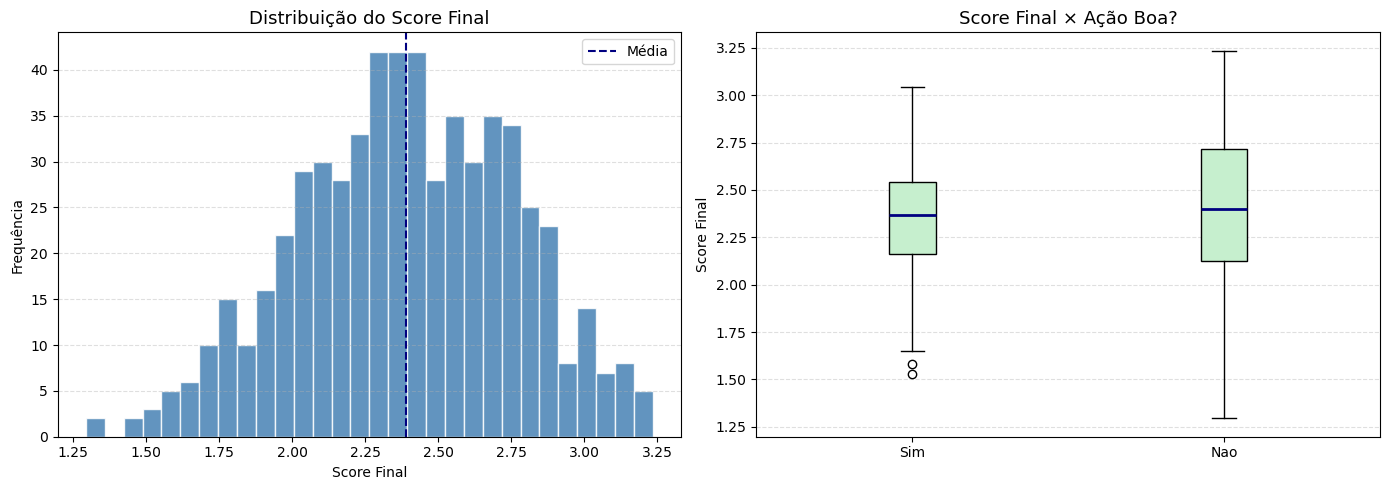

In [38]:
# Visualização do Score Final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_ranking['Score_Final'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df_ranking['Score_Final'].mean(), color='navy', linestyle='--', linewidth=1.5, label='Média')
axes[0].set_title('Distribuição do Score Final', fontsize=13)
axes[0].set_xlabel('Score Final')
axes[0].set_ylabel('Frequência')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Boxplot por Ação Boa?
sim = df_ranking[df_ranking['Ação Boa?'] == 'Sim']['Score_Final']
nao = df_ranking[df_ranking['Ação Boa?'] == 'Nao']['Score_Final']

axes[1].boxplot([sim, nao], labels=['Sim', 'Nao'], patch_artist=True,
                boxprops=dict(facecolor='#C6EFCE'),
                medianprops=dict(color='navy', linewidth=2))

axes[1].set_title('Score Final × Ação Boa?', fontsize=13)
axes[1].set_ylabel('Score Final')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show();

In [37]:
# Top 10 em destaque
print("\nTop 10 ações por Score Final:")
display(df_ranking.head(10))


Top 10 ações por Score Final:


,Papel,Score_Final,Ação Boa?
Rank,,,
1,RPAD5,3.234394,Nao
2,MOAR3,3.187477,Nao
3,CTPC3,3.176066,Nao
4,BRIV4,3.175423,Nao
5,CRIV4,3.175423,Nao
6,SRNA3,3.147608,Nao
7,RPAD3,3.129083,Nao
8,RPAD6,3.129083,Nao
9,RAIA3,3.124124,Nao


1. Quais são as limitações deste modelo?
O modelo apresenta ao menos quatro limitações relevantes:
Estático e retroativo: os critérios de classificação (ex: ROE > 10%, P/L < 15) foram definidos de forma fixa e com base em dados históricos. O modelo não se adapta a mudanças de ciclo econômico, como períodos de alta de juros em que múltiplos historicamente "baratos" deixam de ser atrativos.
Ausência de segmentação setorial: indicadores como Margem Líquida e Dívida/Patrimônio têm comportamentos muito distintos entre setores. Uma margem de 5% pode ser excelente para varejo e insuficiente para tecnologia. Aplicar os mesmos critérios a todos os setores introduz viés sistemático no rankeamento.
Classificação binária simplificada: a definição de "ação boa" exige que a empresa atenda simultaneamente a todos os 4 critérios. Isso ignora empresas que são excepcionais em 3 critérios mas falham em 1 por razão estrutural (ex: empresa de crescimento que naturalmente tem P/L alto).
Sensibilidade ao corte de limpeza: a exclusão de ações com ROE ou P/L negativos, embora justificada, pode eliminar empresas em turnaround — que são justamente oportunidades clássicas de value investing.

2. O Valor da Informação por si só é suficiente para tomar decisões de investimento?
Não. O IV é uma ferramenta de triagem — ele mede o poder discriminante de cada variável em separar "boas" de "ruins" conforme os critérios definidos, mas não captura relações não-lineares entre variáveis nem a dinâmica futura do negócio. O modelo é útil como funil para reduzir o universo de análise de ~600 para ~50–100 ações, mas a decisão final de investimento exige análise qualitativa, contexto setorial e avaliação de gestão.

3. Quais melhorias você recomendaria?
Segmentação por setor: calcular percentis e faixas de IV separadamente por setor (Financeiro, Utilidades, Consumo, etc.), evitando comparar empresas com estruturas de capital e margens naturalmente distintas.
Dados atualizados via API: integrar com APIs como a do Fundamentus, BRAPI ou dados da B3 para atualização automática trimestral, eliminando a dependência de arquivos estáticos.
Incorporar análise de preço e momentum: adicionar variáveis como variação de preço em 52 semanas e volume médio, para identificar não só empresas de qualidade mas também o momento adequado de entrada.

---